In [12]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2

tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# Load dataset
(x_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize images to [-1, 1]
x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)  # (60000, 28, 28, 1)

# One-hot encode labels for conditioning
num_classes = len(np.unique(y_train))
y_train_ohe = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train_ohe)).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


I0000 00:00:1767728253.251675   86480 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13742 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


In [18]:
x_train.shape

(60000, 28, 28, 1)

(-0.5, 27.5, 27.5, -0.5)

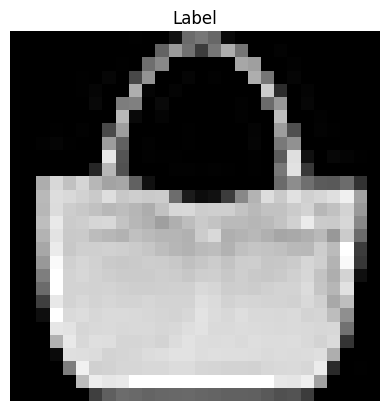

In [17]:
plt.imshow(x_train[100].reshape(28,28) , cmap='gray')
plt.title("Label")
plt.axis('off')

In [3]:
def make_conditional_generator():
    noise_dim = 100
    label_dim = num_classes
    
    noise_input = layers.Input(shape=(noise_dim,))
    label_input = layers.Input(shape=(label_dim,))
    
    # Concatenate noise and label
    x = layers.Concatenate()([noise_input, label_input])
    
    x = layers.Dense(7*7*256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    
    x = layers.Reshape((7,7,256))(x)
    
    x = layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    
    x = layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    
    output = layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', activation='tanh')(x)
    
    model = tf.keras.Model([noise_input, label_input], output)
    return model

generator = make_conditional_generator()


In [4]:
def make_conditional_discriminator():
    image_input = layers.Input(shape=(28,28,1))
    label_input = layers.Input(shape=(num_classes,))
    
    # Expand label to match image spatial dimensions
    label_map = layers.Reshape((1,1,num_classes))(label_input)
    label_map = layers.UpSampling2D(size=(28,28))(label_map)
    
    x = layers.Concatenate()([image_input, label_map])  # Shape: (28,28,1+num_classes)
    
    x = layers.Conv2D(64, (5,5), strides=(2,2), padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(128, (5,5), strides=(2,2), padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Flatten()(x)
    output = layers.Dense(1)(x)
    
    model = tf.keras.Model([image_input, label_input], output)
    return model

discriminator = make_conditional_discriminator()


In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


In [19]:
noise_dim = 100

@tf.function
def train_step(images, labels):
    batch_size = tf.shape(images)[0] 
    noise = tf.random.normal([batch_size, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)

        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(
        gen_loss, generator.trainable_variables
    )
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )


In [20]:
EPOCHS = 50

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch, label_batch in dataset:
            train_step(image_batch, label_batch)
        print(f'Epoch {epoch+1} completed')

train(train_dataset, EPOCHS)


E0000 00:00:1767728647.599286   86480 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-01-06 13:44:10.898086: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1 completed


2026-01-06 13:44:13.024453: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2 completed
Epoch 3 completed


2026-01-06 13:44:17.541271: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed


2026-01-06 13:44:44.634691: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed


2026-01-06 13:45:20.674485: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed
Epoch 50 completed


In [21]:
def generate_category_images(generator, category, num_images=5):
    noise = tf.random.normal([num_images, noise_dim])
    labels = tf.one_hot([category]*num_images, num_classes)
    
    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1) / 2.0  # Rescale [0,1]
    
    fig = plt.figure(figsize=(num_images*2,2))
    for i in range(num_images):
        plt.subplot(1,num_images,i+1)
        plt.imshow(generated_images[i,:,:,0], cmap='gray')
        plt.axis('off')
    plt.show()
    
    return generated_images

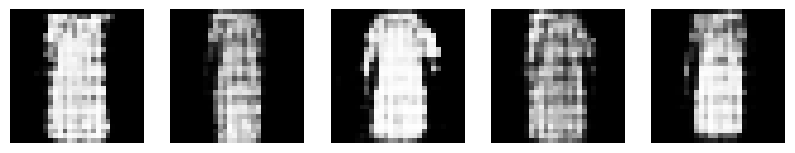

<tf.Tensor: shape=(5, 28, 28, 1), dtype=float32, numpy=
array([[[[1.35332346e-04],
         [2.97725201e-05],
         [5.66244125e-07],
         ...,
         [3.09944153e-06],
         [8.34465027e-07],
         [5.07533550e-05]],

        [[4.76837158e-07],
         [0.00000000e+00],
         [0.00000000e+00],
         ...,
         [0.00000000e+00],
         [0.00000000e+00],
         [6.88433647e-06]],

        [[0.00000000e+00],
         [0.00000000e+00],
         [0.00000000e+00],
         ...,
         [0.00000000e+00],
         [0.00000000e+00],
         [6.27338886e-05]],

        ...,

        [[2.72095203e-05],
         [5.84125519e-06],
         [2.38418579e-07],
         ...,
         [0.00000000e+00],
         [0.00000000e+00],
         [3.87430191e-07]],

        [[5.21838665e-05],
         [4.02033329e-05],
         [5.96046448e-07],
         ...,
         [0.00000000e+00],
         [0.00000000e+00],
         [2.70009041e-05]],

        [[2.81751156e-04],
         [9.7

In [22]:
# Example: Generate 5 dresses (category=3)
generate_category_images(generator, category=3, num_images=5)

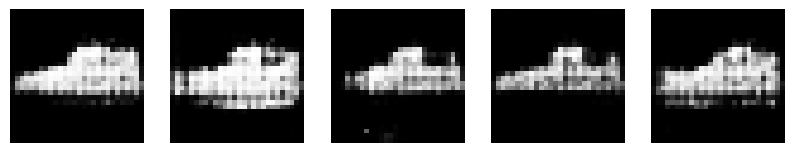

<tf.Tensor: shape=(5, 28, 28, 1), dtype=float32, numpy=
array([[[[5.69286942e-03],
         [2.88969278e-03],
         [3.30865383e-04],
         ...,
         [5.27918339e-04],
         [4.48137522e-04],
         [3.03548574e-03]],

        [[1.15612149e-03],
         [5.34087420e-04],
         [4.77135181e-05],
         ...,
         [1.27911568e-04],
         [4.29749489e-05],
         [8.16166401e-04]],

        [[2.71052122e-04],
         [2.69979239e-04],
         [5.54323196e-06],
         ...,
         [2.42471695e-04],
         [4.24981117e-05],
         [1.26171112e-03]],

        ...,

        [[7.39097595e-06],
         [3.30805779e-06],
         [0.00000000e+00],
         ...,
         [3.04698944e-04],
         [3.26335430e-05],
         [1.51902437e-04]],

        [[3.54647636e-06],
         [1.11758709e-05],
         [0.00000000e+00],
         ...,
         [3.50177288e-05],
         [7.45058060e-07],
         [2.25007534e-05]],

        [[4.46736813e-05],
         [2.9

In [23]:
# Example: Generate 5 sneakers (category=7)
generate_category_images(generator, category=7, num_images=5)